<a href="https://colab.research.google.com/github/arizonaCameraLab/papers/blob/main/DenseHolographicMemories/DAMShift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capacity of shifted multiplexed DAM

## David Brady
## University of Arizona

## written with Anthropic Fable 5.1
## Fall 2026

# Shift-multiplexed holographic dense associative memory: capacity and recall fidelity

This notebook reproduces Fig. 2 of *Dense holographic associative memories* (D. J. Brady and G. Nero). The figure evaluates the baseline architecture of the paper, in which the one-dimensional hidden layer of memory neurons is realized as a line of spherical-reference foci and the stored associations are separated by volume shift selectivity. All device physics is taken from

> G. Barbastathis, M. Levene, and D. Psaltis, "Shift multiplexing with spherical reference waves," *Appl. Opt.* **35**, 2403–2417 (1996),

referred to below as BLP. Equation numbers cited in the code are BLP's.

 Run the cells in order; the figure is written to `sim2_shiftmux.pdf` and `sim2_shiftmux.png` beside the notebook.

## Geometry and parameters

A 2D data page of $N_p \times N_p$ pixels at pitch $b$ is placed in the front focal plane of a lens of focal length $F$, so that the signal reaching the hologram is the Fourier transform of the page, centered on the carrier angle $\theta_S$. The reference for memory neuron $k$ is a spherical wave of numerical aperture $\mathrm{NA}$ focused at position $k\,p\,\delta$ along the shift axis. The hologram has thickness $L$ and refractive index $n_0$, and the recording wavelength is $\lambda_0$.

The baseline parameters are

| symbol | value | meaning |
|---|---|---|
| $\lambda_0$ | 0.5 µm | wavelength |
| $n_0$ | 1.5 | refractive index of the medium |
| $\mathrm{NA}$ | 0.5 | numerical aperture of the spherical reference |
| $\theta_S$ | 30° | signal carrier angle (outside the medium) |
| $b$ | 10 µm | pixel pitch |
| $F$ | 50 mm | Fourier-lens focal length |
| $N_p$ | 128 | page width in pixels (panel a) |
| $p$ | 2 | Bragg-null order of the neighbor spacing (panel a) |

These are set in the dictionary `P`and can be changed freely.

## Panel (a): shift selectivity and memory-neuron count versus thickness

Shifting the medium by $\delta$ relative to the spherical reference detunes the stored grating from the Bragg condition. The shift at which the reconstruction first vanishes is (BLP Eq. 10, with refraction)

$$
\delta \;=\; \frac{\lambda_0\, z_0}{n_0\, L\, \tan\theta_S'} \;+\; \frac{\lambda_0}{2\,\mathrm{NA}},
$$

where $\theta_S'$ is the internal signal angle and $z_0$ is the apparent distance from the reference focus to the medium. The first term is the volume Bragg term and falls as $1/L$; the second is the diffraction-limited spot size of the reference and does not depend on $L$. In practice $z_0$ cannot be held fixed as $L$ grows, because the page must be focused inside the slab; `z0_of_L` implements BLP's thick-medium geometry (Eqs. 33, 40, 41), in which $z_0$ grows linearly with $L$. The two effects together make $\delta$ approach a floor rather than falling indefinitely.

Adjacent memory neurons are placed at spacing $p\,\delta$, i.e., at the $p$-th null of their neighbor's shift response. The number of memory neurons that fit under one signal aperture is then

$$
C \;=\; \frac{s}{p\,\delta\cos\theta_S},
$$

where $s = 2\lambda_0 F/b$ is the Fourier-plane extent of the signal. `code_capacity` returns $C$. Panel (a) plots $\delta$ (left axis) and $C$ (right axis) for $L$ from 30 µm to 10 mm. Because $\delta$ saturates, $C$ rises and then flattens; for the baseline parameters $C \approx 37$, $330$, and $1600$ at $L = 0.1$, $1$, and $10$ mm.

## Panel (b): recall fidelity versus page size

The Bragg null that separates neighbors is exact only for the carrier ray. A pixel at the edge of the page arrives at the hologram tilted away from the carrier and is not fully nulled, so a fraction of its energy leaks into the addressed reconstruction from every neighbor. The tilt of the outermost pixel relative to the carrier is

$$
\beta \;=\; \frac{N_p\, b}{2F\,\sin\theta_S},
$$

which `bandwidth_ratio` computes. For a pixel at fractional tilt $u \in [-\beta, \beta]$, neighbor $m$ contributes crosstalk power $\mathrm{sinc}^2\!\big[p\,(m-m')(1-u)\big]$ (BLP Eq. 14). `crosstalk_power_beta` sums this over the $M-1$ neighbors and averages over $u$ to give the total crosstalk power $P_{\mathrm{XN}}$ relative to unit signal. It is zero at $\beta = 0$ and grows with $\beta$, so larger pages leak more. Because the sum is dominated by the nearest neighbors, $P_{\mathrm{XN}}$ is nearly independent of the total load $M$ once $M$ is more than a few tens.

Recall is modeled at the level of the coefficients delivered to the memory neurons. The target neuron receives amplitude 1; the other $M-1$ neurons receive Gaussian noise whose total power is $P_{\mathrm{XN}}$. Two read-outs are compared:

- **Linear.** The output hologram $H_2$ is read directly with the noisy coefficient vector. Fidelity is the normalized projection of that vector onto the target, $\approx 1/\sqrt{1+P_{\mathrm{XN}}}$. This is what a single-stage or original-Hopfield holographic memory would do.
- **Softmax.** The hidden layer applies $\mathrm{softmax}(\lambda\,\alpha)$ with $\lambda = 8$ before reading $H_2$. Fidelity is the normalized projection of the softmax output onto the target.

Each point averages 80 random draws. Panel (b) plots both read-outs against $N_p$ from 40 to 3000 pixels at fixed $M = 512$, for the densest spacing $p = 1$ and, for the linear read-out, also $p = 2$. Linear recall at $p = 1$ falls to about 0.86 at $N_p = 3000$; spacing at $p = 2$ recovers most of that at half the capacity; the softmax holds recall at 1.0 at $p = 1$, so the hidden-layer nonlinearity is what allows the memory to be packed at full density.

Note that $N_p$ enters only through $\beta$, i.e., through the physical size of the page at fixed pitch and focal length. Doubling the pixel count by halving the pitch at fixed page size would not change the curve.

## Scope of the model

The selectivity, geometry, and interpage crosstalk are BLP's paraxial, Born-approximation, constant-modulation-depth theory, which BLP validated experimentally. The recall model adds one assumption of its own: that crosstalk arrives at the memory neurons as uncorrelated noise. Crosstalk from a neighbor whose stored key genuinely resembles the probe is correlated with the signal and is not represented; that regime is governed by the pattern statistics of the dense associative memory rather than by the holographic geometry, and is outside the scope of this figure. Erasure during multiple exposures and the $M^{-1}$ versus $M^{-2}$ efficiency scaling are treated separately in Sec. 3 of the paper.

## Components

 — device model: `z0_of_L`, `shift_selectivity`, `code_capacity`, `storage_density`, `bandwidth_ratio`, `crosstalk_power_beta`.


Dependencies: `numpy`, `matplotlib`. No data files are required.

In [ ]:
import os
import numpy as np
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
"""
Shift-multiplexing device model for the holographic DAM, from
Barbastathis, Levene & Psaltis, Appl. Opt. 35, 2403 (1996) [BLP].

The 1D hidden layer is a shift axis of spherical-reference points (one per
memory neuron); each stored 2D association occupies one shift position, and the
M associations are separated by the volume shift selectivity. Equation numbers
refer to BLP.

Units: SI (metres, radians) unless noted.
"""




def snell(angle_out, n0):
    """angle inside material from angle outside (sin th = n0 sin th')."""
    return np.arcsin(np.sin(angle_out) / n0)


def z0_of_L(L, params):
    """Apparent focal distance z0 (inside material) vs thickness, BLP Eq (33),(40),(41).
    Thick-medium coefficients (page focused fully inside the slab)."""
    p = params
    thS = p["theta_S"]; NA = p["NA"]
    phi = np.arcsin(NA)                       # reference angular spread, NA = sin phi
    if p["plane"] == "image":
        s = p["Np"] * p["b"]
        chi = np.arcsin(np.clip(p["lam0"] / p["b"], -1, 1))
    else:  # Fourier
        s = 2 * p["lam0"] * p["F"] / p["b"]
        chi = np.arcsin(np.clip(p["Np"] * p["b"] / (2 * p["F"]), -1, 1))
    thS_ = snell(thS, p["n0"]); phi_ = snell(phi, p["n0"]); chi_ = snell(chi, p["n0"])
    A = (s / 2) * (np.cos(chi_) * np.cos(thS_)) / (np.cos(thS_ + chi_) * np.tan(phi_) * np.cos(thS))
    B = 0.5 * np.tan(thS_ + chi_) / np.tan(phi_)
    return A + B * L, thS_, chi_, s


def shift_selectivity(L, params):
    """Shift selectivity delta vs thickness, BLP Eq (10) (with refraction).
    delta = lam0*z0/(n0*L*tan thetaS') + lam0/(2 NA).
    z0 grows ~linearly with L so delta -> floor (capacity saturates)."""
    z0, thS_, chi_, s = z0_of_L(L, params)
    bragg = params["lam0"] * z0 / (params["n0"] * L * np.tan(thS_))
    spot = params["lam0"] / (2 * params["NA"])
    return bragg + spot


def code_capacity(L, params, p_null=2):
    """Number of resolvable memory neurons C = (signal aperture along shift)/(p*delta),
    BLP Section 5."""
    delta = shift_selectivity(L, params)
    thS = params["theta_S"]
    if params["plane"] == "image":
        aperture = params["Np"] * params["b"] / np.cos(thS)
    else:
        aperture = 2 * params["lam0"] * params["F"] / params["b"] / np.cos(thS)
    return aperture / (p_null * delta), delta


def storage_density(L, params, p_null):
    """Surface storage density (bits/m^2), BLP Eq (31)/(32) with pth-null spacing."""
    delta = shift_selectivity(L, params) * p_null
    if params["plane"] == "image":
        return params["Np"] / (2 * params["b"] * delta)
    else:
        return params["Np"]**2 * params["b"] / (4 * params["lam0"] * params["F"] * delta)


def crosstalk_power_beta(M, p_null, beta, n_pix=400):
    """Interpage cross-talk power vs fractional signal bandwidth beta = (signal half-
    spread)/u_S (BLP Eq 14). At beta=0 every neighbour sits on a Bragg null (zero
    crosstalk); off-null pixels detune by (1-u), u in [-beta,beta], and leak."""
    u = np.linspace(-beta, beta, n_pix)
    mprime = M // 2
    m = np.arange(M)
    arg = p_null * (m[None, :] - mprime) * (1 - u[:, None])
    Pp = np.sum(np.sinc(arg)**2, axis=1) - 1.0
    return np.mean(np.clip(Pp, 0, None))


def bandwidth_ratio(Np, params):
    """Fractional signal bandwidth beta = (signal angular half-spread)/u_S, Fourier plane."""
    return Np * params["b"] / (2 * params["F"] * np.sin(params["theta_S"]))


def interpage_crosstalk_power(M, p_null, params, n_pix=200):
    """Expected interpage cross-talk power into the addressed reconstruction, BLP Eq (14),
    averaged over page pixels. Signal power normalised to 1."""
    uS = np.sin(params["theta_S"])
    F = params["F"]
    if params["plane"] == "image":
        half = params["Np"] * params["b"] / 2
    else:
        half = params["lam0"] * F / params["b"]
    xi = np.linspace(-half, half, n_pix)
    mprime = M // 2
    m = np.arange(M)
    arg = p_null * (m[None, :] - mprime) * (1 - xi[:, None] / (uS * F))
    P = np.sum(np.sinc(arg)**2, axis=1) - 1.0
    return np.mean(np.clip(P, 0, None))

(a) L=100um: d=78.20um C=37 | L=1mm: d=8.71um C=332 | L=10mm: d=1.76um C=1644
(b) M=512: p=1 Np=64 lin=0.997 sm=1.000 | p=1 Np=3000 lin=0.863 sm=1.000 | p=2 Np=3000 lin=0.971


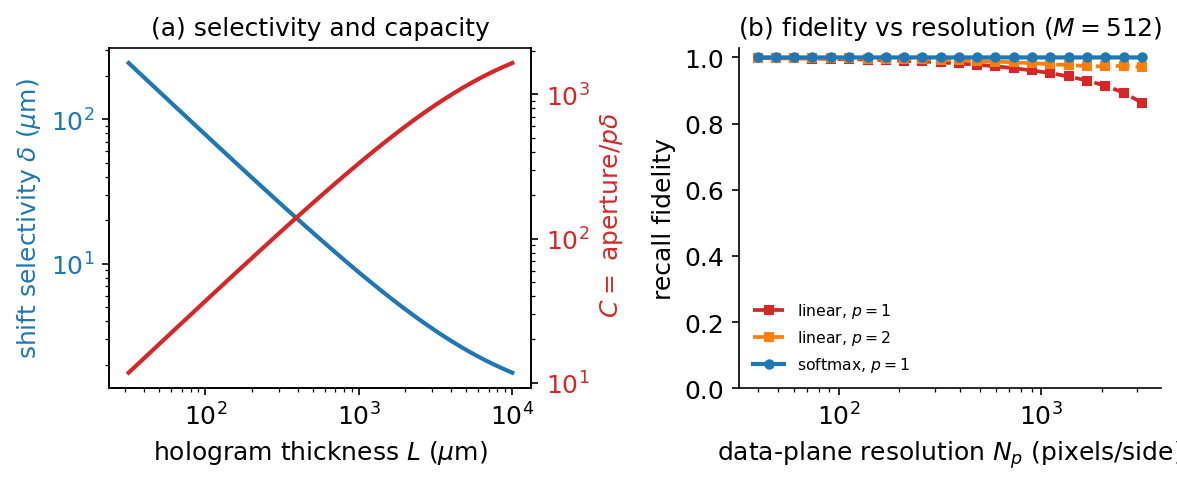

In [ ]:
%matplotlib inline
HERE = os.getcwd()
rng = np.random.default_rng(3)

# ----- baseline DAM device parameters (Fourier-plane signal) -----
P = dict(lam0=0.5e-6, n0=1.5, Np=128, b=10e-6, F=5e-2,
         NA=0.5, theta_S=np.radians(30), plane="Fourier")
p_null = 2                                  # store at 2nd Bragg null

# ============================================================ panel (a)
L_um = np.logspace(1.5, 4, 40)              # 30 um ... 10 mm
L = L_um * 1e-6
delta = np.array([shift_selectivity(Li, P) for Li in L]) * 1e6        # um
Ccap = np.array([code_capacity(Li, P, p_null)[0] for Li in L])        # memory neurons

# ============================================================ panel (c)
def softmax(z, lam):
    z = z - z.max(); w = np.exp(lam * z); return w / w.sum()

Np_list = np.unique(np.round(np.logspace(1.6, 3.5, 22)).astype(int))   # 40 ... 3000 px
M_fix, lam_sm, n_trials = 512, 8.0, 80
fid_lin = np.zeros((2, len(Np_list)))       # rows: p=1, p=2
fid_sm = np.zeros((2, len(Np_list)))
for pi, p in enumerate([1, 2]):
    for j, Np in enumerate(Np_list):
        beta = bandwidth_ratio(Np, P)
        Nx = crosstalk_power_beta(M_fix, p, beta)
        fl, fs = [], []
        for _ in range(n_trials):
            alpha = np.zeros(M_fix); mp = M_fix // 2; alpha[mp] = 1.0
            noise = rng.standard_normal(M_fix); noise[mp] = 0
            noise *= np.sqrt(Nx / (M_fix - 1)) / (np.std(noise[noise != 0]) + 1e-12)
            alpha += noise
            fl.append(alpha[mp] / (np.linalg.norm(alpha) + 1e-12))
            w = softmax(alpha, lam_sm)
            fs.append(w[mp] / (np.linalg.norm(w) + 1e-12))
        fid_lin[pi, j] = np.mean(fl); fid_sm[pi, j] = np.mean(fs)

# ============================================================ figure
plt.rcParams.update({"font.size": 12, "axes.titlesize": 12, "figure.dpi": 150})
fig, ax = plt.subplots(1, 2, figsize=(8.0, 3.4))

# (a) selectivity + capacity vs L
c0, c1 = "C0", "C3"
ax[0].loglog(L_um, delta, color=c0, lw=2)
ax[0].set_xlabel(r"hologram thickness $L$ ($\mu$m)")
ax[0].set_ylabel(r"shift selectivity $\delta$ ($\mu$m)", color=c0)
ax[0].tick_params(axis="y", labelcolor=c0)
ax[0].set_title("(a) selectivity and capacity")
axb = ax[0].twinx()
axb.loglog(L_um, Ccap, color=c1, lw=2)
axb.set_ylabel(r" $C=$ aperture$/p\delta$", color=c1)
axb.tick_params(axis="y", labelcolor=c1)
#axb.text(40, Ccap[-1] * 0.55, "capacity saturates\n($\\delta\\!\\to$ NA/geometry floor)",
#         fontsize=7.5, color=c1, ha="left", va="top")

# (c) recall fidelity vs data-plane resolution
ax[1].semilogx(Np_list, fid_lin[0], "s--", lw=1.8, ms=4, color="C3", label="linear, $p=1$")
ax[1].semilogx(Np_list, fid_lin[1], "s--", lw=1.8, ms=4, color="C1", label="linear, $p=2$")
ax[1].semilogx(Np_list, fid_sm[0], "o-", lw=2, ms=4, color="C0", label="softmax, $p=1$")
ax[1].set_xlabel(r"data-plane resolution $N_p$ (pixels/side)")
ax[1].set_ylabel("recall fidelity")
ax[1].set_title(rf"(b) fidelity vs resolution ($M={M_fix}$)")
ax[1].set_ylim(0, 1.03)
ax[1].legend(frameon=False, loc="lower left", fontsize=7.5)

for a in (ax[0], ax[1], ax[1]):
    a.spines["top"].set_visible(False)
ax[1].spines["right"].set_visible(False)
ax[1].spines["right"].set_visible(False)
fig.tight_layout()

fig.savefig(os.path.join(HERE, "sim2_shiftmux.pdf"), bbox_inches="tight")
#fig.savefig(os.path.join(HERE, "sim2_shiftmux.png"), bbox_inches="tight", dpi=150)

print("(a) L=100um: d=%.2fum C=%.0f | L=1mm: d=%.2fum C=%.0f | L=10mm: d=%.2fum C=%.0f"
      % (shift_selectivity(1e-4, P)*1e6, code_capacity(1e-4, P, p_null)[0],
         shift_selectivity(1e-3, P)*1e6, code_capacity(1e-3, P, p_null)[0],
         shift_selectivity(1e-2, P)*1e6, code_capacity(1e-2, P, p_null)[0]))
print("(b) M=512: p=1 Np=64 lin=%.3f sm=%.3f | p=1 Np=3000 lin=%.3f sm=%.3f | p=2 Np=3000 lin=%.3f"
      % (fid_lin[0, np.argmin(abs(Np_list-64))], fid_sm[0, np.argmin(abs(Np_list-64))],
         fid_lin[0, -1], fid_sm[0, -1], fid_lin[1, -1]))